In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df=pd.read_csv('E:\data_science\ML_PROJECT\Student Depression Dataset.csv')
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [4]:
df.shape

(27901, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [6]:
df['Depression'].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [7]:
df.isna().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [8]:
df.drop(columns='id',inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df.dropna()

In [11]:
print("Work Pressure zeros:", (df['Work Pressure'] == 0).sum())
print("Job Satisfaction zeros:", (df['Job Satisfaction'] == 0).sum())
print()
print("Work Pressure non-zeros:", (df['Work Pressure'] != 0).sum())
print("Job Satisfaction non-zeros:", (df['Job Satisfaction'] != 0).sum())

Work Pressure zeros: 27895
Job Satisfaction zeros: 27890

Work Pressure non-zeros: 3
Job Satisfaction non-zeros: 8


In [12]:
print("CGPA zeros:", (df['CGPA'] == 0).sum())
print("CGPA non-zeros:", (df['CGPA'] != 0).sum())

CGPA zeros: 9
CGPA non-zeros: 27889


In [13]:
 df.drop(columns=['CGPA'],inplace=True)

In [14]:
 df.drop(columns=['City'],inplace=True)

In [15]:
df['Profession'].value_counts()

Profession
Student                   27867
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64

In [16]:
df.drop(columns=['Profession'],inplace=True)

In [17]:
df['Sleep Duration'].value_counts()

Sleep Duration
Less than 5 hours    8309
7-8 hours            7346
5-6 hours            6181
More than 8 hours    6044
Others                 18
Name: count, dtype: int64

In [18]:
df = df[df['Sleep Duration'] != 'Others']

In [19]:
df['Dietary Habits'].value_counts()

Dietary Habits
Unhealthy    10308
Moderate      9914
Healthy       7646
Others          12
Name: count, dtype: int64

In [20]:
df = df[df['Dietary Habits'] != 'Others']

In [21]:
df['Have you ever had suicidal thoughts ?'] = df[
    'Have you ever had suicidal thoughts ?'
].map({'Yes':1,'No':0})

In [22]:
df['Have you ever had suicidal thoughts ?'].unique()

array([1, 0])

In [23]:
df['Family History of Mental Illness'] = df[
    'Family History of Mental Illness'
].map({'Yes':1,'No':0})

In [24]:
df['Family History of Mental Illness'].unique()

array([0, 1])

In [25]:
df['Financial Stress'].fillna(
    df['Financial Stress'].median(),
    inplace=True
)

C:\Users\prais\AppData\Local\Temp\ipykernel_22516\2106474416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Financial Stress'].fillna(


In [26]:
df.drop(
    ['Work Pressure', 'Job Satisfaction'],
    axis=1,
    inplace=True
)

In [27]:
df.columns

Index(['Gender', 'Age', 'Academic Pressure', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27868 entries, 0 to 27900
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27868 non-null  object 
 1   Age                                    27868 non-null  float64
 2   Academic Pressure                      27868 non-null  float64
 3   Study Satisfaction                     27868 non-null  float64
 4   Sleep Duration                         27868 non-null  object 
 5   Dietary Habits                         27868 non-null  object 
 6   Degree                                 27868 non-null  object 
 7   Have you ever had suicidal thoughts ?  27868 non-null  int64  
 8   Work/Study Hours                       27868 non-null  float64
 9   Financial Stress                       27868 non-null  float64
 10  Family History of Mental Illness       27868 non-null  int64  
 11  Depress

In [29]:
num_columns = ['Age', 'Academic Pressure', 
               'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']

In [30]:
for col in num_columns:
    print(f"--- {col} ---")
    print(df.groupby('Depression')[col].mean())
    print()

--- Age ---
Depression
0    27.143463
1    24.884851
Name: Age, dtype: float64

--- Academic Pressure ---
Depression
0    2.361558
1    3.693283
Name: Academic Pressure, dtype: float64

--- Study Satisfaction ---
Depression
0    3.215498
1    2.751256
Name: Study Satisfaction, dtype: float64

--- Work/Study Hours ---
Depression
0    6.238355
1    7.808800
Name: Work/Study Hours, dtype: float64

--- Financial Stress ---
Depression
0    2.519134
1    3.579728
Name: Financial Stress, dtype: float64



In [31]:
cat_columns = ['Gender', 'Sleep Duration', 
               'Dietary Habits', 'Degree', 
               'Have you ever had suicidal thoughts ?', 
               'Family History of Mental Illness']

In [32]:
for col in cat_columns:
    print(f"{col}: {df[col].unique()}")
    print(f"Total unique values: {df[col].nunique()}")
    print()

Gender: ['Male' 'Female']
Total unique values: 2

Sleep Duration: ['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours']
Total unique values: 4

Dietary Habits: ['Healthy' 'Moderate' 'Unhealthy']
Total unique values: 3

Degree: ['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech' 'PhD' 'Class 12' 'B.Ed' 'LLB' 'BE'
 'M.Ed' 'MSc' 'BHM' 'M.Pharm' 'MCA' 'MA' 'B.Com' 'MD' 'MBA' 'MBBS' 'M.Com'
 'B.Arch' 'LLM' 'B.Tech' 'BBA' 'ME' 'MHM' 'Others']
Total unique values: 28

Have you ever had suicidal thoughts ?: [1 0]
Total unique values: 2

Family History of Mental Illness: [0 1]
Total unique values: 2



In [33]:
df['Depression'].value_counts()

Depression
1    16318
0    11550
Name: count, dtype: int64

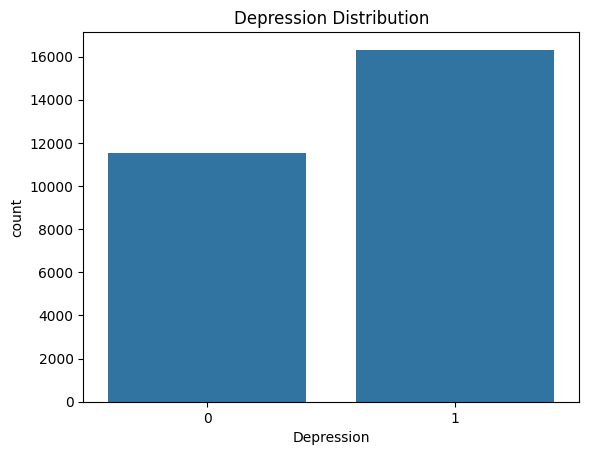

In [34]:
sns.countplot(x='Depression', data=df)
plt.title('Depression Distribution')
plt.show()

In [35]:
num_cols = df.select_dtypes(include=np.number).columns

print(num_cols)


Index(['Age', 'Academic Pressure', 'Study Satisfaction',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


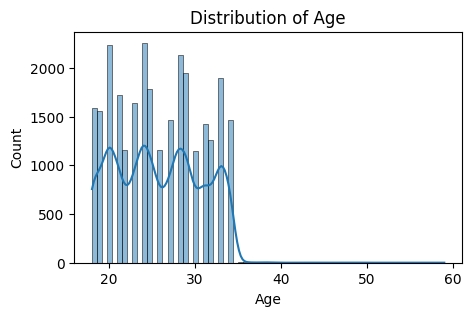

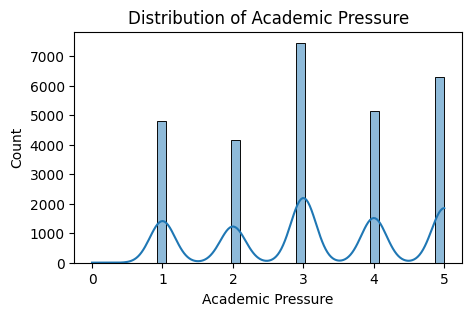

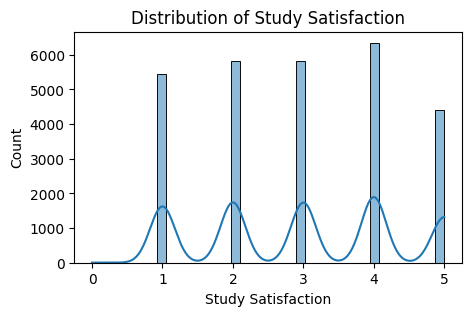

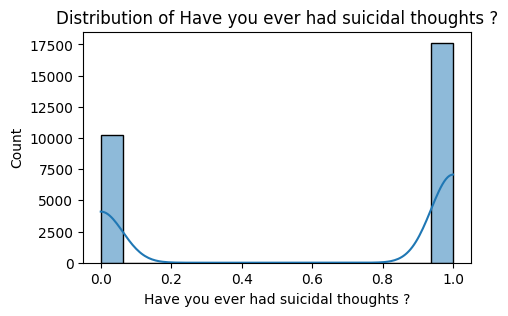

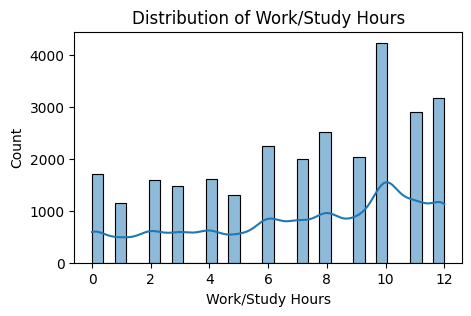

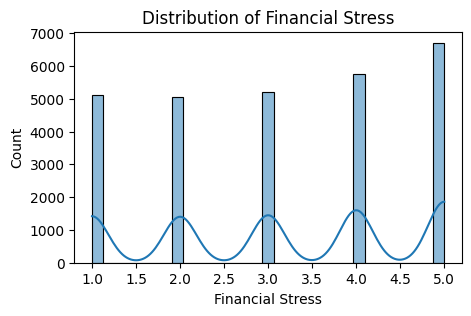

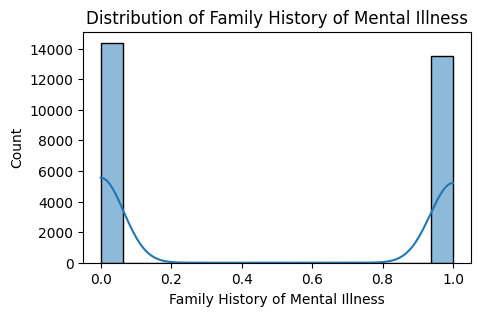

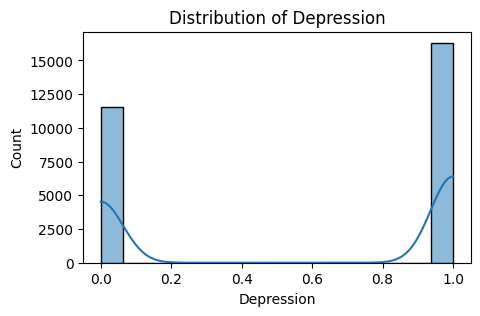

In [36]:
for col in num_cols:
    
    plt.figure(figsize=(5,3))
    
    sns.histplot(
        df[col],
        kde=True
    )
    
    plt.title(f'Distribution of {col}')
    
    plt.show()

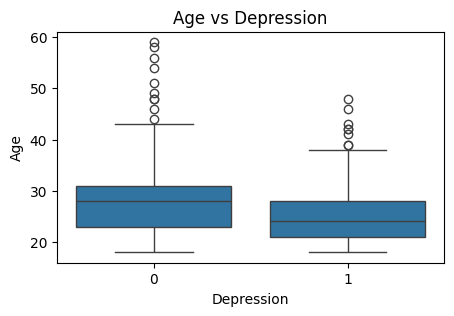

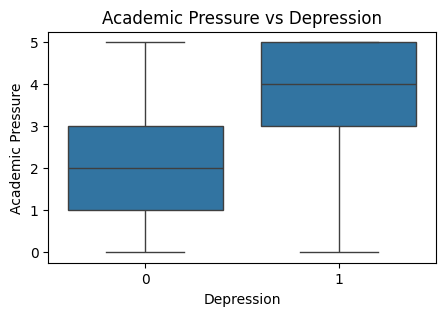

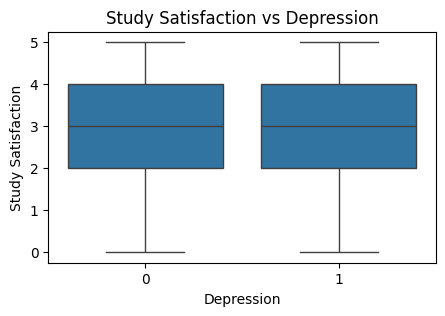

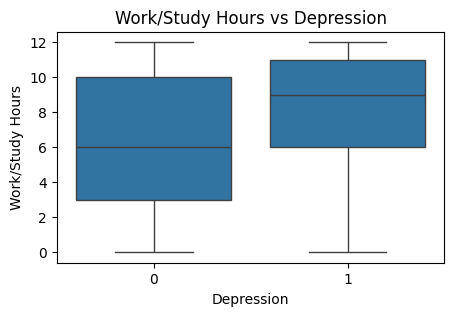

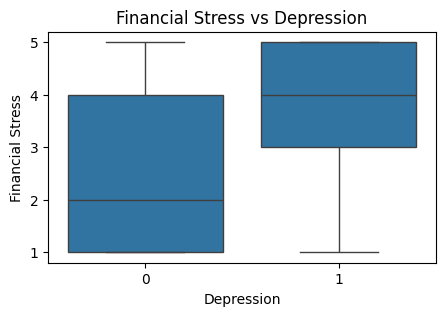

In [37]:
num_columns = ['Age', 'Academic Pressure', 
               'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']
for col in num_columns:
    
    if col != 'Depression':
        
        plt.figure(figsize=(5,3))
        
        sns.boxplot(
            x='Depression',
            y=col,
            data=df
        )
        
        plt.title(f'{col} vs Depression')
        
        plt.show()

In [38]:
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['Gender', 'Sleep Duration', 'Dietary Habits', 'Degree'], dtype='object')


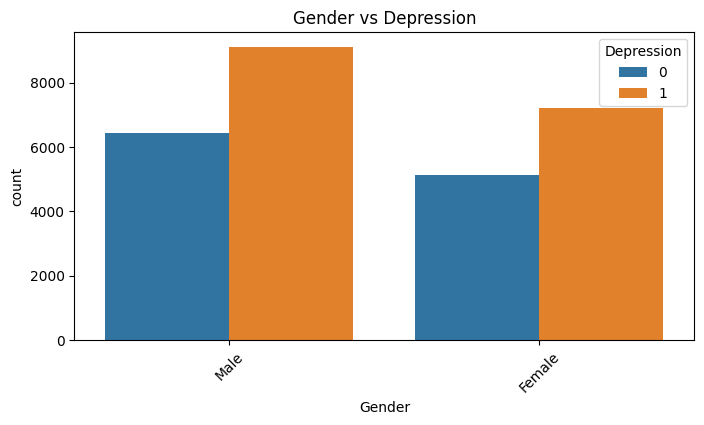

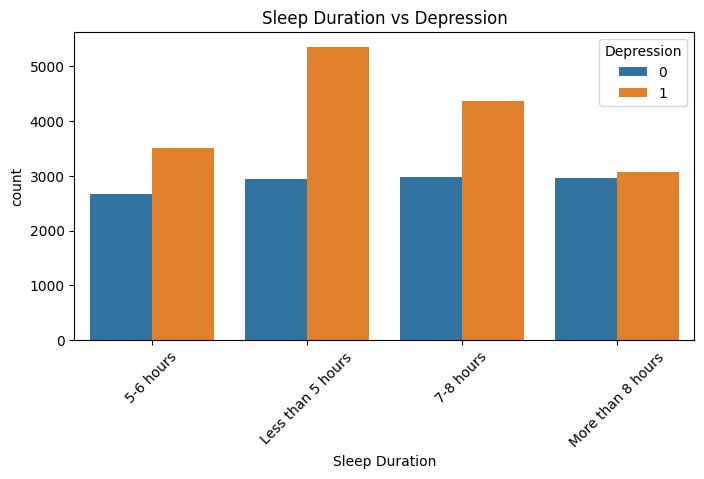

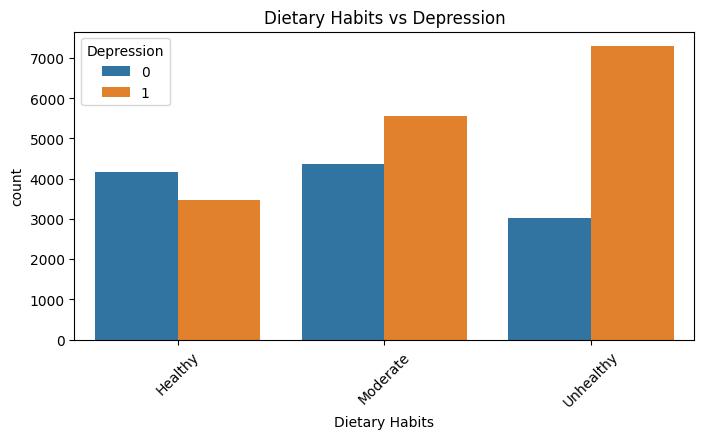

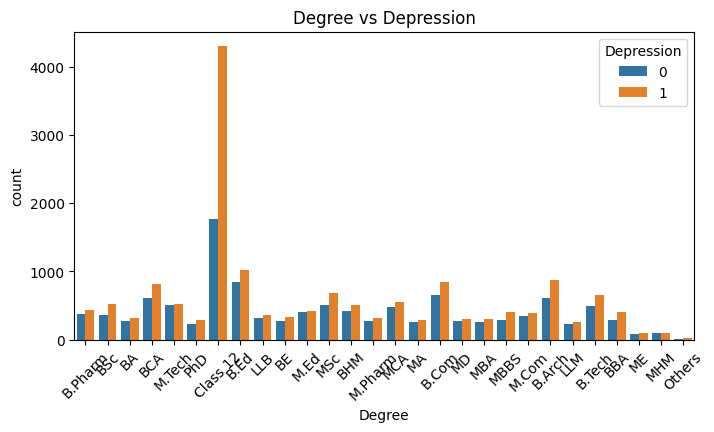

In [39]:

for col in cat_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.countplot(
        x=col,
        hue='Depression',
        data=df
    )
    
    plt.xticks(rotation=45)
    
    plt.title(f'{col} vs Depression')
    
    plt.show()

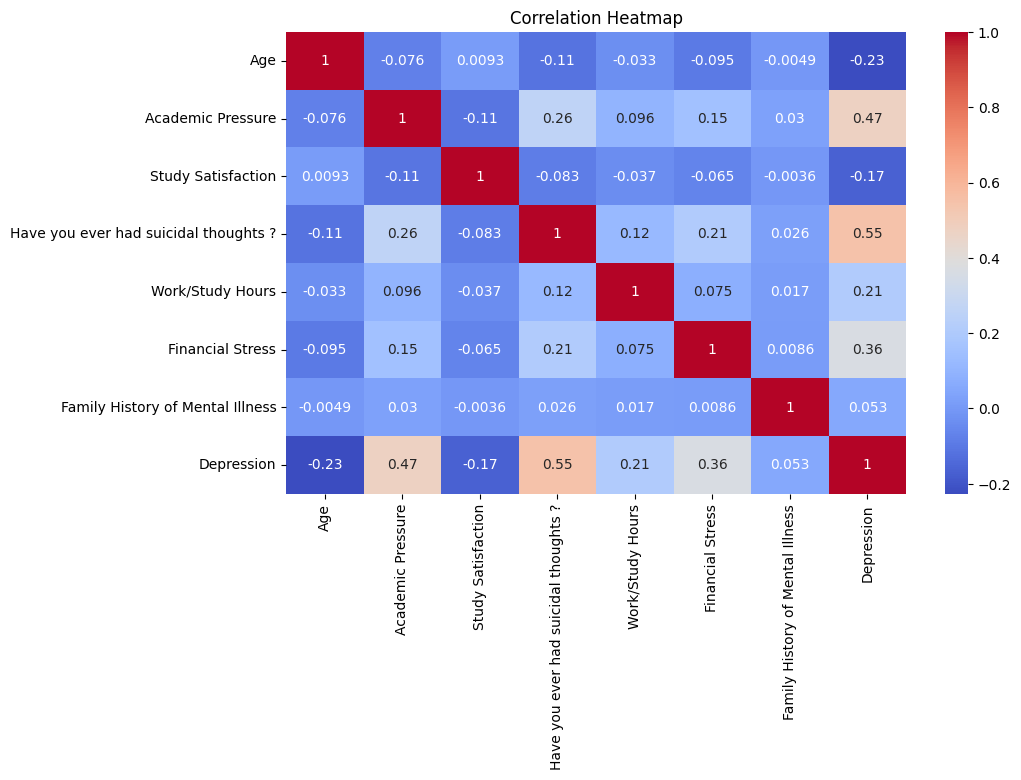

In [40]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

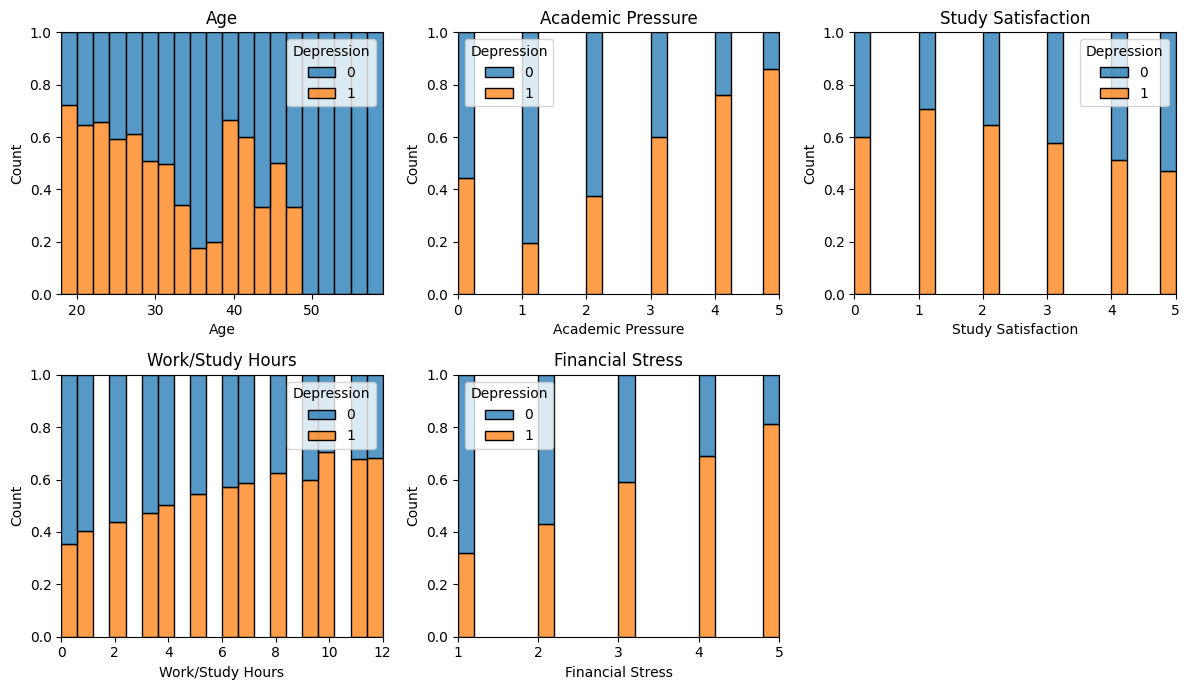

In [41]:
num_columns = ['Age', 'Academic Pressure', 
               'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(12,7))
for i, col in enumerate(num_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='Depression', bins=20, multiple='fill')
    plt.title(col)
plt.tight_layout()
plt.show()

In [42]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()
corr

,Age,Academic Pressure,Study Satisfaction,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
Age,1.000000,-0.076312,0.009319,-0.113526,-0.033072,-0.094870,-0.004852,-0.226812
Academic Pressure,-0.076312,1.000000,-0.111183,0.261556,0.095907,0.151976,0.029793,0.474847
Study Satisfaction,0.009319,-0.111183,1.000000,-0.083384,-0.036650,-0.065196,-0.003588,-0.168038
Have you ever had suicidal thoughts ?,-0.113526,0.261556,-0.083384,1.000000,0.121790,0.209158,0.026137,0.546396
Work/Study Hours,-0.033072,0.095907,-0.036650,0.121790,1.000000,0.075189,0.017483,0.208693
Financial Stress,-0.094870,0.151976,-0.065196,0.209158,0.075189,1.000000,0.008555,0.363526
Family History of Mental Illness,-0.004852,0.029793,-0.003588,0.026137,0.017483,0.008555,1.000000,0.053344
Depression,-0.226812,0.474847,-0.168038,0.546396,0.208693,0.363526,0.053344,1.000000


In [43]:
df['Degree'].unique()

array(['B.Pharm', 'BSc', 'BA', 'BCA', 'M.Tech', 'PhD', 'Class 12', 'B.Ed',
       'LLB', 'BE', 'M.Ed', 'MSc', 'BHM', 'M.Pharm', 'MCA', 'MA', 'B.Com',
       'MD', 'MBA', 'MBBS', 'M.Com', 'B.Arch', 'LLM', 'B.Tech', 'BBA',
       'ME', 'MHM', 'Others'], dtype=object)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27868 entries, 0 to 27900
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27868 non-null  object 
 1   Age                                    27868 non-null  float64
 2   Academic Pressure                      27868 non-null  float64
 3   Study Satisfaction                     27868 non-null  float64
 4   Sleep Duration                         27868 non-null  object 
 5   Dietary Habits                         27868 non-null  object 
 6   Degree                                 27868 non-null  object 
 7   Have you ever had suicidal thoughts ?  27868 non-null  int64  
 8   Work/Study Hours                       27868 non-null  float64
 9   Financial Stress                       27868 non-null  float64
 10  Family History of Mental Illness       27868 non-null  int64  
 11  Depress

In [45]:
df['Gender'] = df['Gender'].map({
    'Male':1,
    'Female':0
})

In [46]:


le = LabelEncoder()

df['Degree'] = le.fit_transform(df['Degree'])

In [47]:
x= df.drop('Depression', axis=1)

y = df['Depression']

In [48]:


x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
num_columns = [
    'Age',
    'Academic Pressure',
    'Study Satisfaction',
    'Work/Study Hours',
    'Financial Stress'
]

In [50]:
ordinal_columns = [
    'Sleep Duration',
    'Dietary Habits'
]

In [51]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

In [52]:
ordinal_pipeline = Pipeline([
    
    ('oe', OrdinalEncoder(categories=[
        
        ['Less than 5 hours',
         '5-6 hours',
         '7-8 hours',
         'More than 8 hours'],
        
        ['Unhealthy',
         'Moderate',
         'Healthy']
    ])),
    
    ('scaler', StandardScaler())
])

In [53]:
preprocessor = ColumnTransformer([
    
    ('num', num_pipeline, num_columns),
    
    ('ord', ordinal_pipeline,
     ['Sleep Duration','Dietary Habits'])
])

In [54]:
x_train_transformed = preprocessor.fit_transform(x_train)

x_test_transformed = preprocessor.transform(x_test)

Model : Logistic Regression
Accuracy Score : 0.7997847147470398

Confusion Matrix :

[[1686  639]
 [ 477 2772]]


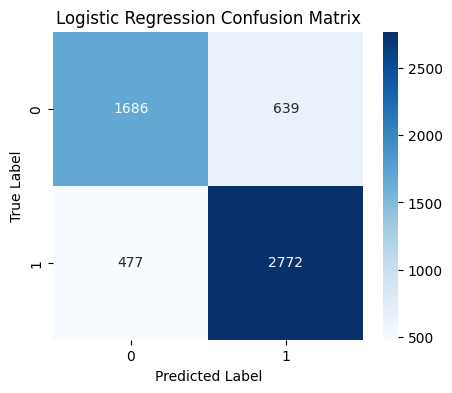


Classification Report :

              precision    recall  f1-score   support

           0       0.78      0.73      0.75      2325
           1       0.81      0.85      0.83      3249

    accuracy                           0.80      5574
   macro avg       0.80      0.79      0.79      5574
weighted avg       0.80      0.80      0.80      5574




Model : Decision Tree
Accuracy Score : 0.7118765697883028

Confusion Matrix :

[[1530  795]
 [ 811 2438]]


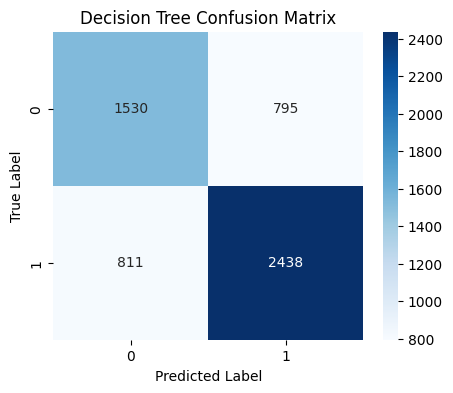


Classification Report :

              precision    recall  f1-score   support

           0       0.65      0.66      0.66      2325
           1       0.75      0.75      0.75      3249

    accuracy                           0.71      5574
   macro avg       0.70      0.70      0.70      5574
weighted avg       0.71      0.71      0.71      5574




Model : Random Forest
Accuracy Score : 0.7823824901327593

Confusion Matrix :

[[1649  676]
 [ 537 2712]]


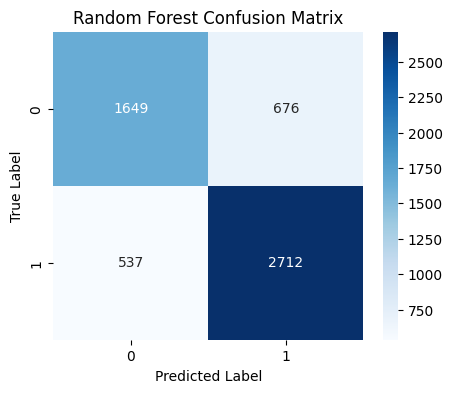


Classification Report :

              precision    recall  f1-score   support

           0       0.75      0.71      0.73      2325
           1       0.80      0.83      0.82      3249

    accuracy                           0.78      5574
   macro avg       0.78      0.77      0.77      5574
weighted avg       0.78      0.78      0.78      5574




Model : KNN
Accuracy Score : 0.7743092931467528

Confusion Matrix :

[[1623  702]
 [ 556 2693]]


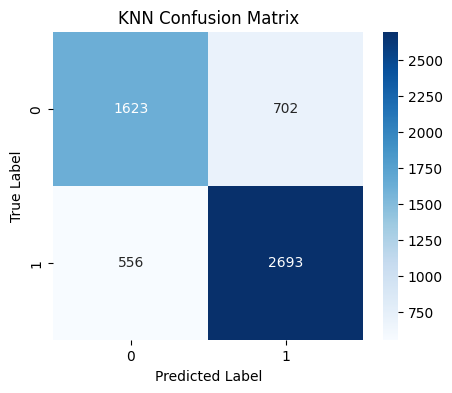


Classification Report :

              precision    recall  f1-score   support

           0       0.74      0.70      0.72      2325
           1       0.79      0.83      0.81      3249

    accuracy                           0.77      5574
   macro avg       0.77      0.76      0.77      5574
weighted avg       0.77      0.77      0.77      5574




Model : Naive Bayes
Accuracy Score : 0.7997847147470398

Confusion Matrix :

[[1697  628]
 [ 488 2761]]


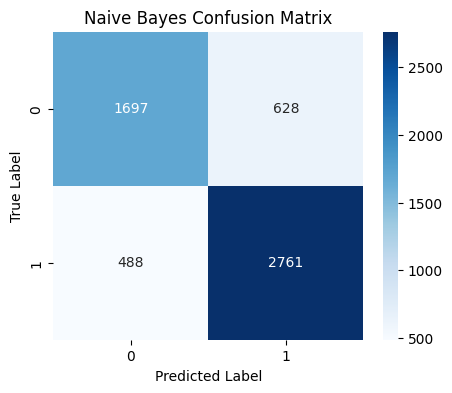


Classification Report :

              precision    recall  f1-score   support

           0       0.78      0.73      0.75      2325
           1       0.81      0.85      0.83      3249

    accuracy                           0.80      5574
   macro avg       0.80      0.79      0.79      5574
weighted avg       0.80      0.80      0.80      5574






In [55]:
models = {
    
    'Logistic Regression' : LogisticRegression(C=0.1,
    max_iter=1000)
    
    ,'Decision Tree' : DecisionTreeClassifier(),
    
    'Random Forest' : RandomForestClassifier(
     n_estimators=300,
     max_depth=15,
     random_state=42
 ),
    
    'KNN' : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
    
    # 'SVM' : SVC(
    #  C=10,
    #  kernel='rbf',
    #  gamma='scale'
    #  )
}
for name, model in models.items():
    print('='*50)
    print(f'Model : {name}')
    print('='*50)

    model.fit(
        x_train_transformed,
        y_train
    )
    y_pred = model.predict(
        x_test_transformed
    )
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    
    print(f'Accuracy Score : {accuracy}')

    cm = confusion_matrix(
        y_test,
        y_pred
    )
    
    print('\nConfusion Matrix :\n')
    
    print(cm)

    plt.figure(figsize=(5,4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    
    plt.xlabel('Predicted Label')
    
    plt.ylabel('True Label')
    
    plt.title(f'{name} Confusion Matrix')
    
    plt.show()


    print('\nClassification Report :\n')
    
    print(
        classification_report(
            y_test,
            y_pred
        )
    )
    
    print('\n\n')
    






In [56]:


scores = cross_val_score(
    model,
    x_train_transformed,
    y_train,
    cv=5
)

print(scores.mean())
    

0.7986006897397564


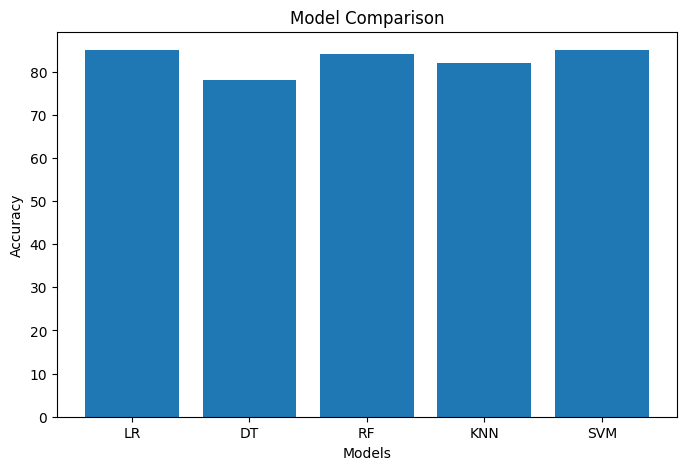

In [57]:
model_names = ['LR', 'DT', 'RF', 'KNN', 'SVM']

accuracies = [85, 78, 84, 82, 85]

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.title('Model Comparison')

plt.show()

In [58]:
import pickle

with open('model.pkl', 'wb') as file:
    
    pickle.dump(model, file)

In [59]:
with open('preprocessor.pkl', 'wb') as file:
    
    pickle.dump(preprocessor, file)

In [60]:
print(df['Depression'].value_counts())

Depression
1    16318
0    11550
Name: count, dtype: int64
